###  MicroGrad demo

In [1]:
# 基础库与绘图库
import random
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline


In [2]:
# 导入 micrograd 的自动求导与网络模块
from micrograd.engine import Value
from micrograd.nn import Neuron, Layer, MLP


In [3]:
# 固定随机种子，保证结果可复现
np.random.seed(1337)
random.seed(1337)


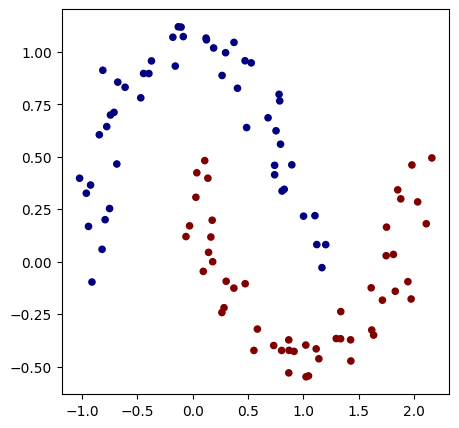

In [4]:
# 构造一个二维玩具数据集（两个月牙）
from sklearn.datasets import make_moons, make_blobs
X, y = make_moons(n_samples=100, noise=0.1)

# 将标签从 {0,1} 映射到 {-1,1}
y = y*2 - 1 # make y be -1 or 1
# 可视化数据分布
plt.figure(figsize=(5,5))
plt.scatter(X[:,0], X[:,1], c=y, s=20, cmap='jet')


In [5]:
# 初始化一个多层感知机：输入2维，隐藏层16-16，输出1维
model = MLP(2, [16, 16, 1]) # 2-layer neural network
print(model)
print('number of parameters', len(model.parameters()))

MLP of [Layer of [ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2)], Layer of [ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16)], Layer of [LinearNeuron(16)]]
number of parameters 337


In [46]:
Xb = X[:3]
inputs = [list(map(Value, xrow)) for xrow in Xb]
# 前向计算得到分数
scores = list(map(model, inputs))
scores

[Value(data=-0.24267959107182535, grad=0),
 Value(data=-1.243357473239418, grad=0),
 Value(data=-0.5369900872329142, grad=0)]

In [48]:
# 定义损失函数：SVM hinge loss + L2 正则，并返回准确率
def loss(batch_size=None):
    
    # 简易的 DataLoader：可选小批量抽样
    if batch_size is None:
        Xb, yb = X, y
    else:
        # 随机打乱索引，取前 batch_size 个，形成小批量 Xb, yb
        ri = np.random.permutation(X.shape[0])[:batch_size]
        Xb, yb = X[ri], y[ri]
    # 将 numpy 数组转换为 micrograd 的 Value 对象
    # map(Value, xrow)：把 xrow 里的每个数都包成 Value
    inputs = [list(map(Value, xrow)) for xrow in Xb]
    
    # 前向计算得到分数
    scores = list(map(model, inputs))
    
    # SVM 的 hinge loss：max(0, 1 - y*s)
    losses = [(1 + -yi*scorei).relu() for yi, scorei in zip(yb, scores)]
    data_loss = sum(losses) * (1.0 / len(losses))
    # L2 正则，防止参数过大
    alpha = 1e-4
    reg_loss = alpha * sum((p*p for p in model.parameters()))
    total_loss = data_loss + reg_loss
    
    # 计算准确率：符号是否一致
    accuracy = [(yi > 0) == (scorei.data > 0) for yi, scorei in zip(yb, scores)]
    return total_loss, sum(accuracy) / len(accuracy)

total_loss, acc = loss()
print(total_loss, acc)


Value(data=0.8958441028683222, grad=0) 0.5


In [49]:
# 训练：前向 -> 反向 -> 参数更新（SGD）
for k in range(100):
    
    # 前向
    total_loss, acc = loss()
    
    # 反向
    model.zero_grad()
    total_loss.backward()
    
    # 参数更新（线性衰减学习率）
    learning_rate = 1.0 - 0.9*k/100
    for p in model.parameters():
        p.data -= learning_rate * p.grad
    
    if k % 1 == 0:
        print(f'step {k} loss {total_loss.data}, accuracy {acc*100}%')


step 0 loss 0.8958441028683222, accuracy 50.0%
step 1 loss 1.723590533697202, accuracy 81.0%
step 2 loss 0.7429006313851131, accuracy 77.0%
step 3 loss 0.7705641260584201, accuracy 82.0%
step 4 loss 0.3692793385976538, accuracy 84.0%
step 5 loss 0.313545481918522, accuracy 86.0%
step 6 loss 0.2814234349772435, accuracy 89.0%
step 7 loss 0.26888733313983904, accuracy 91.0%
step 8 loss 0.2567147286057416, accuracy 91.0%
step 9 loss 0.27048625516379227, accuracy 91.0%
step 10 loss 0.24507023853658047, accuracy 91.0%
step 11 loss 0.25099055297915035, accuracy 92.0%
step 12 loss 0.21560951851922952, accuracy 91.0%
step 13 loss 0.23090378446402735, accuracy 93.0%
step 14 loss 0.20152151227899445, accuracy 92.0%
step 15 loss 0.22574506279282222, accuracy 93.0%
step 16 loss 0.19447987596204103, accuracy 92.0%
step 17 loss 0.21089496199246363, accuracy 93.0%
step 18 loss 0.15983077356303602, accuracy 94.0%
step 19 loss 0.1845374874688392, accuracy 93.0%
step 20 loss 0.1897752285608764, accuracy

(-1.548639298268643, 1.951360701731357)

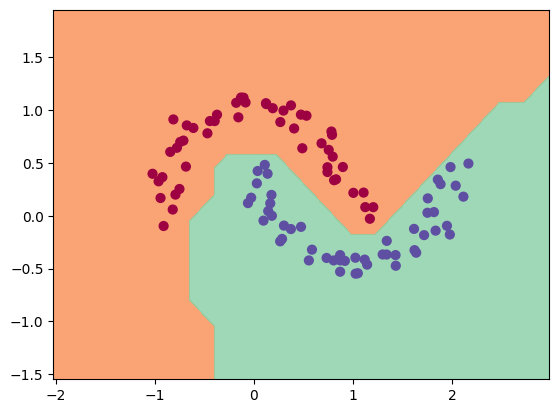

In [76]:
# 可视化决策边界

h = 0.25
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
# 在 x/y 范围内生成规则网格点（二维平面上的所有采样点）。xx是x坐标，yy是y坐标
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))
# Xmesh 形状是 (N, 2)，每行就是一个坐标点 [x, y]
Xmesh = np.c_[xx.ravel(), yy.ravel()] # ravel() 展平，np.c_ 列拼接

# 对每个网格点进行预测，得到分数列表
inputs = [list(map(Value, xrow)) for xrow in Xmesh]
scores = list(map(model, inputs))

# 把分数转成类别（正类为 True，负类为 False）
Z = np.array([s.data > 0 for s in scores])
Z = Z.reshape(xx.shape)

fig = plt.figure()
plt.contourf(xx, yy, Z, cmap=plt.cm.Spectral, alpha=0.8)
plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.Spectral)
plt.xlim(xx.min(), xx.max())
plt.ylim(yy.min(), yy.max())